# Generate hillshaded DEA Intertidal animations

## Getting started
Set working directory to top level of repo to ensure links work correctly:

In [2]:
cd ../..

/home/jovyan/Robbi/dea-intertidal


Install additional packages directly from the requirements file

In [ ]:
pip install -e .

### Load packages

In [3]:
%load_ext autoreload
%autoreload 2

import datacube
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ipyleaflet import basemap_to_tiles, basemaps
from odc.geo import Geometry
from odc.ui import select_on_a_map
from IPython.display import Video

import xarray as xr
from dea_tools.dask import create_local_dask_cluster
from dea_tools.plotting import xr_animation
from intertidal.utils import intertidal_hillshade

# Connect to datacube
dc = datacube.Datacube(app="Intertidal_elevation_animation")

# Set up Dask cluster
client = create_local_dask_cluster(return_client=True)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 64,Total memory: 456.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42157,Workers: 0
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38183,Total threads: 64
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/40863/status,Memory: 456.00 GiB
Nanny: tcp://127.0.0.1:40219,


## Load data

Map(center=[-26, 135], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_t…

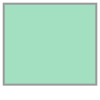

In [11]:
# OPTIONAL: Plot interactive map to select area
basemap = basemap_to_tiles(basemaps.Esri.WorldImagery)
geom_dc18 = select_on_a_map(height="600px", layers=(basemap,), center=(-26, 135), zoom=4)
geom_dc19 = Geometry(geom_dc18.geom, crs=geom_dc18.crs)
name = "interactive"
query_params = dict(geopolygon=geom_dc19)
geom_dc19

In [44]:
# # Cape Capricorn
# name = "capecapricorn"
# t, l = -23.491, 151.150
# b, r = -23.531, 151.241
# query_params = dict(x=(l, r), y=(t, b))

# # Burdekin
# name = "burdekin"
# t, l = -19.615, 147.555
# b, r = -19.659, 147.615
# query_params = dict(x=(l, r), y=(t, b))

# # Pilbara
# name = "pilbara"
# t, l = -20.76, 116.44
# b, r = -20.825, 116.53
# query_params = dict(x=(l, r), y=(t, b))

# # Spoilbank
# name = "spoilbank"
# t, l = -20.28, 118.575
# b, r = -20.32, 118.66
# query_params = dict(x=(l, r), y=(t, b))

# # King Sound
# name = "kingsound"
# t, l = -16.98, 123.23
# b, r = -17.04, 123.30
# query_params = dict(x=(l, r), y=(t, b))

# # Carnot Bay
name = "carnotbay"
t, l = -17.11, 122.22
b, r = -17.19, 122.31
query_params = dict(x=(l, r), y=(t, b))

In [53]:
ds.time

<xarray.DataArray 'time' (time: 9)> Size: 72B
array(['2016-07-01T23:59:59.999999000', '2017-07-02T11:59:59.999999000',
       '2018-07-02T11:59:59.999999000', '2019-07-02T11:59:59.999999000',
       '2020-07-01T23:59:59.999999000', '2021-07-02T11:59:59.999999000',
       '2022-07-02T11:59:59.999999000', '2023-07-02T11:59:59.999999000',
       '2024-07-01T23:59:59.999999000'], dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 72B 2016-07-01T23:59:59.999999 ... 202...
    spatial_ref  int32 4B 3577
Attributes:
    units:    seconds since 1970-01-01 00:00:00

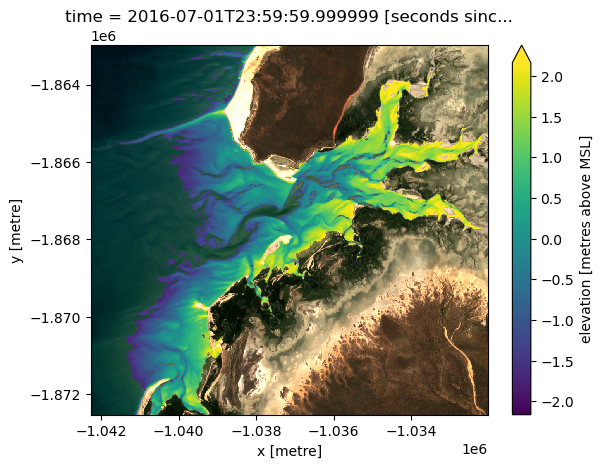

In [45]:
# Load DEA Intertidal data
ds = dc.load(
    product="ga_s2ls_intertidal_cyear_3",
    measurements=["elevation", "qa_ndwi_freq"],
    dask_chunks={},
    **query_params,
).compute()

# Load RGB imagery from tidal composites
ds_rgb = dc.load(
    product="ga_s2_tidal_composites_cyear_3",
    measurements=["low_red", "low_green", "low_blue"],
    like=ds.odc.geobox,
    dask_chunks={},
).compute()

# Fill any missing data in RGB with next available timestep
ds_rgb = ds_rgb.where(ds_rgb != -999).bfill(dim="time")

# Preview the outputs
ds_rgb.isel(time=0).to_array().plot.imshow(robust=True)
ds.isel(time=0).elevation.plot.imshow(ax=plt.gca(), cmap="viridis", robust=True)

## Prepare data

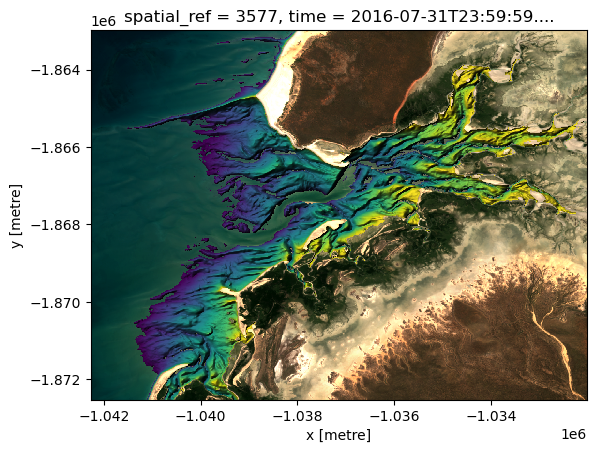

In [50]:
# Calculate minimum and maximum quantile values to stretch elevation between
vmin, vmax = ds.elevation.quantile([0.03, 0.95]).values


# Hillshade rapper function that takes a single timestep Dataset
def _generate_hillshade(ds_step):
    return intertidal_hillshade(
        elevation=ds_step.elevation.squeeze(),
        freq=ds_step.qa_ndwi_freq.squeeze(),
        altdeg=45,
        vert_exag=500,
        vmin=vmin,
        vmax=vmax,
        fraction=1,
    )


# Apply hillshading to each timestep
intertidal_da = ds.groupby("time").map(_generate_hillshade)

# Mask valid pixels to remove pixels that only appear rarely
valid_data_mask = ds.elevation.notnull().mean(dim="time") > 0.3
intertidal_da = intertidal_da.where(valid_data_mask)

# Convert imagery to RGBA
vmin, vmax = ds_rgb.to_array().quantile([0.01, 0.99]).values
ds_rgba = ds_rgb.odc.to_rgba(vmin=vmin, vmax=vmax).rename(band="variables")

# Blend RGBA and hillshade data
intertidal_ds = (
    intertidal_da.fillna(ds_rgba * 1.2)  # make background RGBA slightly washed out
    .clip(0, 255)
    .astype(np.uint8)
    .to_dataset(dim="variables")
)

# Interpolate to add additional frames
intertidal_interpolated_ds = intertidal_ds.interp(
    time=pd.date_range(
        intertidal_ds.time[0].values,
        intertidal_ds.time[-1].values,
        freq="2ME",
        inclusive="both",
    )
)
intertidal_interpolated_ds.isel(time=0).to_array().plot.imshow(vmin=0, vmax=255)

## Animate data

Exporting animation to notebooks/visualisation/DEA Intertidal - 2016-2024 - carnotbay.mp4


  0%|          | 0/48 (0.0 seconds remaining at ? frames/s)

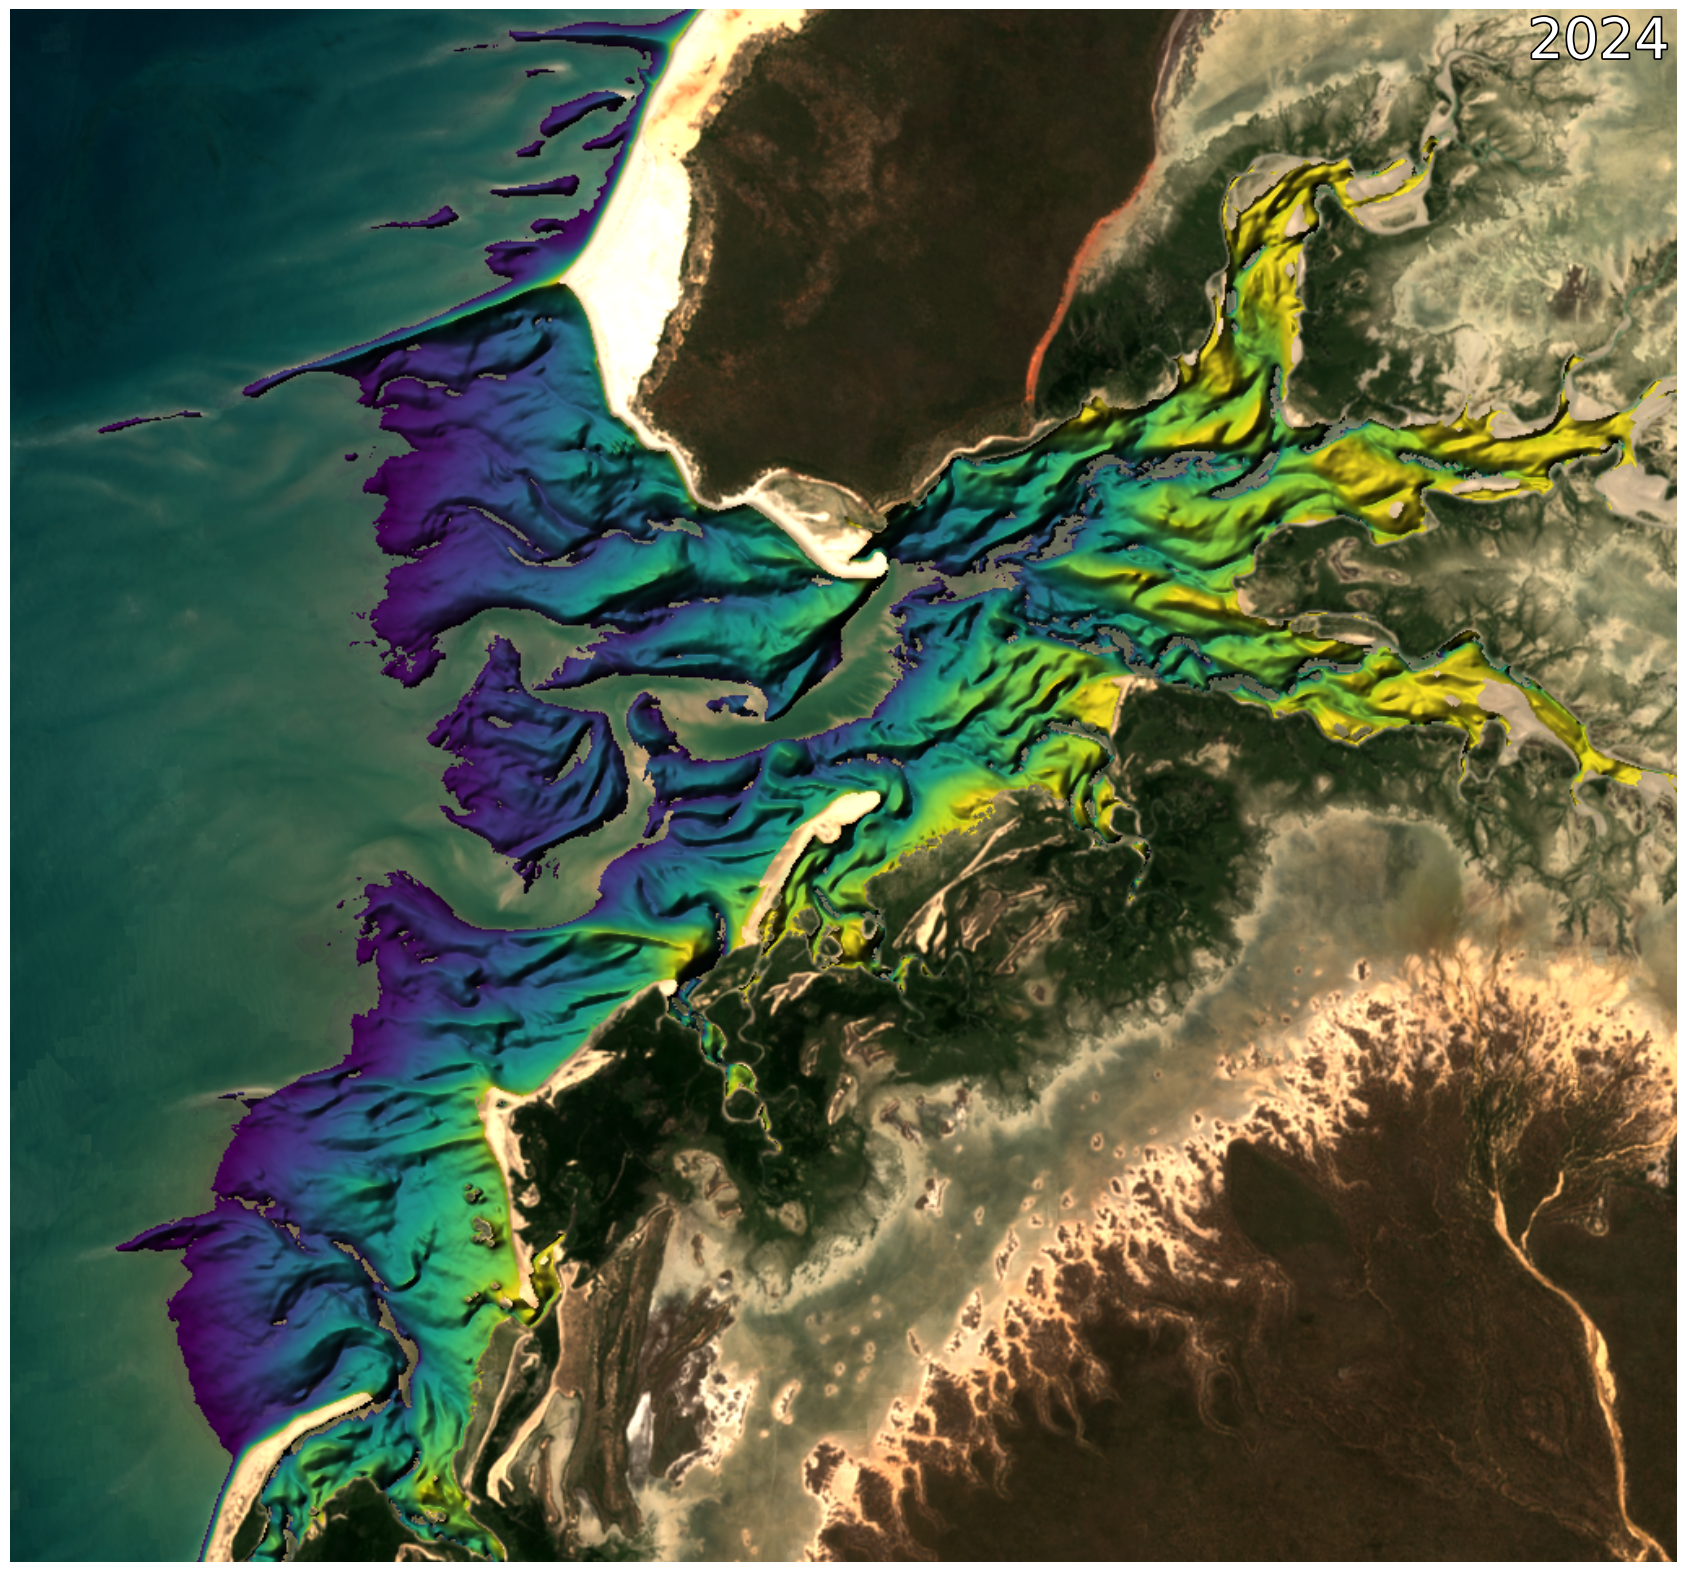

In [51]:
for ext in [
    ".mp4",
    # ".gif",
]:

    fname = f"notebooks/visualisation/DEA Intertidal - {ds.time.dt.year[0].item()}-{ds.time.dt.year[-1].item()} - {name}{ext}"
    xr_animation(
        ds=intertidal_interpolated_ds,
        bands=["r", "g", "b"],
        imshow_kwargs={"vmin": 0, "vmax": 255, "interpolation": "bilinear"},
        output_path=fname,
        interval=40,
        show_date="%Y",
        width_pixels=1200,
        annotation_kwargs={"fontsize": 40},
        # limit=3,
    )
    Video(fname, embed=True, width=600, html_attributes="loop autoplay")

## Experimental: export DEM and RGB imagery for visualisation
This can be used to create a continuous psuedo DEM that covers the entire analysis area by filling the upper and lower areas of the map with the highest and lowest elevations from the intertidal DEM.

In [ ]:
freq = ds.qa_ndwi_freq.copy()
elev = ds.elevation.copy()
elev_min, elev_max = elev.quantile([0, 1])

dem = xr.where(elev.isnull() & (freq < 50), elev_max, elev).fillna(elev_min)

In [ ]:
dem.isel(time=7).plot.imshow()

In [ ]:
ds_rgb.isel(time=0).to_array().odc.write_cog("rgb.tif")

In [ ]:
dem.odc.assign_crs(crs=ds_rgb.odc.crs).isel(time=0).odc.write_cog("dem.tif")